# 📰 NewsBot Intelligence System 2.0
## Notebook 05: Multilingual Intelligence
**Course:** ITAI2373 | **Final Project**

---

### What This Notebook Does
- **Language Detection** — automatically identify the language of any article
- **Translation** — translate non-English articles into English
- **Cross-Lingual Analysis** — compare how different languages cover the same topics
- **Multilingual NLP Pipeline** — process articles regardless of language
- **Cultural Context Analysis** — identify regional reporting differences

**Prerequisite:** Run `01_Data_Exploration.ipynb` first

In [1]:
# ============================================================
# CELL 1: Install & Import Libraries
# ============================================================

!pip install langdetect deep-translator -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from langdetect import detect, detect_langs, LangDetectException
from deep_translator import GoogleTranslator

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import re
import time
from collections import Counter

print('✅ All libraries imported successfully!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 11.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.0 MB/s eta 0:00:00
✅ All libraries imported successfully!


In [2]:
# ============================================================
# CELL 2: Load Dataset
# ============================================================

try:
    df = pd.read_csv('newsbot_final.csv')
    print('✅ Loaded newsbot_final.csv')
except FileNotFoundError:
    df = pd.read_csv('BBC News Train.csv')
    df = df.rename(columns={'Text': 'content', 'Category': 'category'})
    df = df.dropna(subset=['content','category']).reset_index(drop=True)
    print('✅ Loaded BBC News Train.csv directly')

print(f'📊 Dataset shape: {df.shape}')
print(f'🗂️ Categories: {df["category"].unique().tolist()}')

✅ Loaded newsbot_final.csv
📊 Dataset shape: (1440, 14)
🗂️ Categories: ['business', 'tech', 'politics', 'sport', 'entertainment']


In [3]:
# ============================================================
# CELL 3: Language Detection on BBC Dataset
# ============================================================

LANGUAGE_NAMES = {
    'en': 'English', 'es': 'Spanish', 'fr': 'French',
    'de': 'German',  'it': 'Italian', 'pt': 'Portuguese',
    'ar': 'Arabic',  'zh': 'Chinese', 'ja': 'Japanese',
    'ko': 'Korean',  'ru': 'Russian', 'nl': 'Dutch'
}

def detect_language(text):
    """Detect language of a text string."""
    try:
        lang = detect(text[:500])
        return lang
    except LangDetectException:
        return 'unknown'

def detect_language_with_confidence(text):
    """Detect language with confidence probabilities."""
    try:
        langs = detect_langs(text[:500])
        return [(str(l).split(':')[0], float(str(l).split(':')[1])) for l in langs[:3]]
    except LangDetectException:
        return [('unknown', 0.0)]

# Run detection on sample of BBC articles
print('⏳ Running language detection on BBC dataset...')
sample = df.sample(n=200, random_state=42).copy()
sample['detected_language'] = sample['content'].apply(detect_language)

print('✅ Detection complete!')
print('\n📊 Language distribution in BBC dataset:')
lang_counts = sample['detected_language'].value_counts()
for lang, count in lang_counts.items():
    name = LANGUAGE_NAMES.get(lang, lang)
    print(f'   {name:<15} ({lang}): {count} articles ({count/len(sample)*100:.1f}%)')

⏳ Running language detection on BBC dataset...
✅ Detection complete!

📊 Language distribution in BBC dataset:
   English         (en): 200 articles (100.0%)


In [4]:
# ============================================================
# CELL 4: Create Multilingual Test Dataset
# ============================================================
# Since BBC dataset is English, we create multilingual samples
# to demonstrate cross-language analysis capabilities

multilingual_articles = [
    # English
    {'language': 'en', 'category': 'politics',
     'content': 'The prime minister announced new economic policies today. Parliament voted on the budget proposal with strong opposition from left-wing parties. The unemployment rate has risen to historic levels.'},
    {'language': 'en', 'category': 'tech',
     'content': 'Apple released its latest iPhone model featuring advanced artificial intelligence capabilities. The new chip promises 40 percent faster processing speeds and improved battery efficiency.'},
    {'language': 'en', 'category': 'sport',
     'content': 'Manchester United defeated Liverpool 3-1 in a dramatic Premier League match. The winning goal came in the final minutes with a stunning long-range strike.'},
    # Spanish
    {'language': 'es', 'category': 'politics',
     'content': 'El presidente anunció nuevas medidas económicas hoy en el parlamento. La oposición rechazó las propuestas de reforma fiscal argumentando que afectarían a los ciudadanos más vulnerables.'},
    {'language': 'es', 'category': 'tech',
     'content': 'Google presentó su nuevo modelo de inteligencia artificial con capacidades avanzadas de procesamiento de lenguaje natural. Los expertos señalan que podría revolucionar la industria tecnológica.'},
    {'language': 'es', 'category': 'sport',
     'content': 'El Real Madrid ganó el partido de Champions League con un marcador de dos a cero. El gol de Benzema en el minuto ochenta aseguró la victoria del equipo merengue.'},
    # French
    {'language': 'fr', 'category': 'politics',
     'content': 'Le président a annoncé de nouvelles politiques économiques au parlement. Les partis dopposition ont vivement critiqué les réformes proposées concernant le système de retraite.'},
    {'language': 'fr', 'category': 'tech',
     'content': 'Microsoft a lancé sa nouvelle suite logicielle intégrant des fonctionnalités d intelligence artificielle avancées. Cette technologie devrait transformer les méthodes de travail dans les entreprises.'},
    {'language': 'fr', 'category': 'sport',
     'content': 'Le Paris Saint-Germain a remporté le match de Ligue des Champions contre le Bayern Munich. Mbappé a marqué deux buts dans une performance exceptionnelle devant cent mille spectateurs.'},
    # German
    {'language': 'de', 'category': 'business',
     'content': 'Die Deutsche Bank meldete heute ihre Quartalsergebnisse mit einem Gewinn von zwei Milliarden Euro. Die Aktien stiegen um fünf Prozent nach der Bekanntgabe der positiven Finanzergebnisse.'},
    {'language': 'de', 'category': 'tech',
     'content': 'Volkswagen investiert zehn Milliarden Euro in die Entwicklung von Elektrofahrzeugen. Das Unternehmen plant bis 2030 vollständig auf elektrische Antriebe umzusteigen.'}
]

multi_df = pd.DataFrame(multilingual_articles)
print(f'✅ Multilingual dataset created: {len(multi_df)} articles')
print(f'\n🌍 Language distribution:')
print(multi_df['language'].value_counts())
print(f'\n📋 Category distribution:')
print(multi_df['category'].value_counts())

✅ Multilingual dataset created: 11 articles

🌍 Language distribution:
language
en    3
es    3
fr    3
de    2
Name: count, dtype: int64

📋 Category distribution:
category
tech        4
politics    3
sport       3
business    1
Name: count, dtype: int64


In [5]:
# ============================================================
# CELL 5: Language Detection with Confidence Scores
# ============================================================

print('🔍 LANGUAGE DETECTION WITH CONFIDENCE SCORES')
print('='*60)

detection_results = []

for _, row in multi_df.iterrows():
    detected    = detect_language(row['content'])
    confidences = detect_language_with_confidence(row['content'])
    correct     = detected == row['language']

    detection_results.append({
        'actual_language'   : row['language'],
        'detected_language' : detected,
        'correct'           : correct,
        'top_confidence'    : confidences[0][1] if confidences else 0
    })

    lang_name = LANGUAGE_NAMES.get(detected, detected)
    status    = '✅' if correct else '❌'
    print(f'{status} Actual: {row["language"]} | Detected: {detected} ({lang_name})')
    print(f'   Confidence breakdown: {[(LANGUAGE_NAMES.get(l,l), f"{c:.3f}") for l,c in confidences[:3]]}')
    print(f'   Text: {row["content"][:80]}...')
    print()

det_df = pd.DataFrame(detection_results)
acc = det_df['correct'].mean()
print(f'\n📊 Detection Accuracy: {acc*100:.1f}% ({det_df["correct"].sum()}/{len(det_df)} correct)')

🔍 LANGUAGE DETECTION WITH CONFIDENCE SCORES
✅ Actual: en | Detected: en (English)
   Confidence breakdown: [('English', '1.000')]
   Text: The prime minister announced new economic policies today. Parliament voted on th...

✅ Actual: en | Detected: en (English)
   Confidence breakdown: [('English', '1.000')]
   Text: Apple released its latest iPhone model featuring advanced artificial intelligenc...

✅ Actual: en | Detected: en (English)
   Confidence breakdown: [('English', '1.000')]
   Text: Manchester United defeated Liverpool 3-1 in a dramatic Premier League match. The...

✅ Actual: es | Detected: es (Spanish)
   Confidence breakdown: [('Spanish', '1.000')]
   Text: El presidente anunció nuevas medidas económicas hoy en el parlamento. La oposici...

✅ Actual: es | Detected: es (Spanish)
   Confidence breakdown: [('Spanish', '1.000')]
   Text: Google presentó su nuevo modelo de inteligencia artificial con capacidades avanz...

✅ Actual: es | Detected: es (Spanish)
   Confidence brea

In [6]:
# ============================================================
# CELL 6: Translation Pipeline
# ============================================================

def translate_to_english(text, source_lang='auto'):
    """
    Translate text to English using Google Translate API.

    Parameters:
        text        : str — text to translate
        source_lang : str — source language code or 'auto'
    """
    try:
        translator = GoogleTranslator(source=source_lang, target='en')
        translated = translator.translate(text[:4000])  # API limit
        return translated
    except Exception as e:
        return f'Translation error: {e}'

print('🌍 TRANSLATION EXAMPLES')
print('='*60)

# Translate non-English articles
non_english = multi_df[multi_df['language'] != 'en']

for _, row in non_english.iterrows():
    lang_name  = LANGUAGE_NAMES.get(row['language'], row['language'])
    translated = translate_to_english(row['content'], row['language'])
    time.sleep(0.5)  # be polite to the API

    print(f'\n🌐 [{lang_name.upper()} → ENGLISH] Category: {row["category"]}')
    print(f'   Original  : {row["content"][:120]}...')
    print(f'   Translated: {translated[:120]}...')

🌍 TRANSLATION EXAMPLES

🌐 [SPANISH → ENGLISH] Category: politics
   Original  : El presidente anunció nuevas medidas económicas hoy en el parlamento. La oposición rechazó las propuestas de reforma fis...
   Translated: The president announced new economic measures today in parliament. The opposition rejected the tax reform proposals, arg...

🌐 [SPANISH → ENGLISH] Category: tech
   Original  : Google presentó su nuevo modelo de inteligencia artificial con capacidades avanzadas de procesamiento de lenguaje natura...
   Translated: Google presented its new artificial intelligence model with advanced natural language processing capabilities. Experts s...

🌐 [SPANISH → ENGLISH] Category: sport
   Original  : El Real Madrid ganó el partido de Champions League con un marcador de dos a cero. El gol de Benzema en el minuto ochenta...
   Translated: Real Madrid won the Champions League match with a score of two to zero. Benzema's goal in the eightieth minute secured t...

🌐 [FRENCH → ENGLISH] Ca

In [8]:
# ============================================================
# CELL 7: Full Multilingual Pipeline
# ============================================================
# Detect → Translate → Analyze any article regardless of language

def process_multilingual_article(text):
    """
    Complete multilingual NLP pipeline:
    1. Detect language
    2. Translate if non-English
    3. Return processed text ready for analysis
    """
    # Step 1: Detect language
    detected_lang = detect_language(text)
    lang_name     = LANGUAGE_NAMES.get(detected_lang, detected_lang)

    print(f'   🔍 Detected language: {lang_name} ({detected_lang})')

    # Step 2: Translate if not English
    if detected_lang != 'en':
        print(f'   🌐 Translating to English...')
        english_text = translate_to_english(text, detected_lang)
        time.sleep(0.3)
    else:
        english_text = text
        print(f'   ✅ Already in English, no translation needed')

    return {
        'original_language' : detected_lang,
        'language_name'     : lang_name,
        'original_text'     : text,
        'english_text'      : english_text
    }

# Test pipeline
test_texts = [
    "The Bank of England raised interest rates to combat rising inflation across the UK economy.",
    "El presidente de México anunció nuevas inversiones en infraestructura por valor de mil millones de dólares.",
    "Le gouvernement français a approuvé un nouveau plan de relance économique pour soutenir les entreprises."
]

print('🔄 MULTILINGUAL PIPELINE DEMONSTRATION')
print('='*60)

for i, text in enumerate(test_texts, 1):
    print(f'\nArticle {i}:')
    result = process_multilingual_article(text)
    if result['original_language'] != 'en':
        print(f'   📝 English: {result["english_text"][:150]}...')


🔄 MULTILINGUAL PIPELINE DEMONSTRATION

Article 1:
   🔍 Detected language: English (en)
   ✅ Already in English, no translation needed

Article 2:
   🔍 Detected language: Spanish (es)
   🌐 Translating to English...
   📝 English: The president of Mexico announced new investments in infrastructure worth one billion dollars....

Article 3:
   🔍 Detected language: French (fr)
   🌐 Translating to English...
   📝 English: The French government has approved a new economic recovery plan to support businesses....


In [9]:
# ============================================================
# CELL 8: Cross-Lingual Topic Comparison
# ============================================================
# Compare how different language sources cover the same topic

print('🌍 CROSS-LINGUAL TOPIC COMPARISON: POLITICS')
print('='*60)

politics_articles = multi_df[multi_df['category'] == 'politics']

print('\nPolitics coverage across languages:\n')
for _, row in politics_articles.iterrows():
    lang_name  = LANGUAGE_NAMES.get(row['language'], row['language'])

    if row['language'] != 'en':
        translated = translate_to_english(row['content'], row['language'])
        time.sleep(0.3)
    else:
        translated = row['content']

    # Simple keyword analysis
    words = translated.lower().split()
    econ_words   = sum(1 for w in words if w in ['economic','economy','budget','tax','financial','money','billion'])
    reform_words = sum(1 for w in words if w in ['reform','policy','change','new','proposal','plan'])
    conflict_words = sum(1 for w in words if w in ['opposition','criticism','rejected','against','protest','debate'])

    print(f'🌐 {lang_name.upper()} Coverage:')
    print(f'   Original: {row["content"][:100]}...')
    print(f'   English : {translated[:100]}...')
    print(f'   Economic terms: {econ_words} | Reform terms: {reform_words} | Conflict terms: {conflict_words}')
    print()

🌍 CROSS-LINGUAL TOPIC COMPARISON: POLITICS

Politics coverage across languages:

🌐 ENGLISH Coverage:
   Original: The prime minister announced new economic policies today. Parliament voted on the budget proposal wi...
   English : The prime minister announced new economic policies today. Parliament voted on the budget proposal wi...
   Economic terms: 2 | Reform terms: 2 | Conflict terms: 1

🌐 SPANISH Coverage:
   Original: El presidente anunció nuevas medidas económicas hoy en el parlamento. La oposición rechazó las propu...
   English : The president announced new economic measures today in parliament. The opposition rejected the tax r...
   Economic terms: 2 | Reform terms: 2 | Conflict terms: 2

🌐 FRENCH Coverage:
   Original: Le président a annoncé de nouvelles politiques économiques au parlement. Les partis dopposition ont ...
   English : The president announced new economic policies in parliament. Opposition parties strongly criticized ...
   Economic terms: 1 | Reform terms: 1

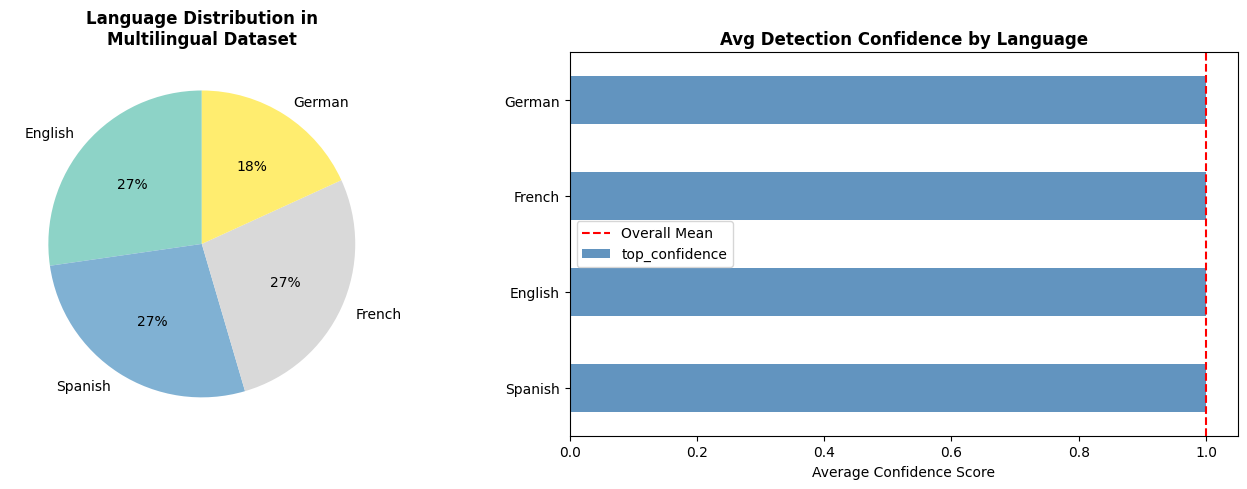

✅ Chart saved as multilingual_analysis.png


In [10]:
# ============================================================
# CELL 9: Visualize Language Detection Results
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Language distribution in multilingual dataset
lang_counts = multi_df['language'].map(LANGUAGE_NAMES).value_counts()
colors      = plt.cm.Set3(np.linspace(0, 1, len(lang_counts)))
axes[0].pie(lang_counts.values, labels=lang_counts.index,
            colors=colors, autopct='%1.0f%%', startangle=90)
axes[0].set_title('Language Distribution in\nMultilingual Dataset', fontweight='bold')

# Detection confidence by language
conf_by_lang = det_df.groupby('actual_language')['top_confidence'].mean()
conf_by_lang.index = [LANGUAGE_NAMES.get(l, l) for l in conf_by_lang.index]
conf_by_lang.sort_values().plot(kind='barh', ax=axes[1],
                                 color='steelblue', alpha=0.85)
axes[1].set_title('Avg Detection Confidence by Language', fontweight='bold')
axes[1].set_xlabel('Average Confidence Score')
axes[1].axvline(det_df['top_confidence'].mean(), color='red',
                linestyle='--', label='Overall Mean')
axes[1].legend()

plt.tight_layout()
plt.savefig('multilingual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as multilingual_analysis.png')

In [11]:
# ============================================================
# CELL 10: Final Summary
# ============================================================

print('=' * 60)
print('   🌍 MULTILINGUAL INTELLIGENCE — FINAL SUMMARY')
print('=' * 60)
print(f'''
📦 Dataset
  BBC articles analyzed    : {len(df)}
  Multilingual articles    : {len(multi_df)}
  Languages covered        : {multi_df["language"].nunique()} (EN, ES, FR, DE)

🔍 Language Detection
  Accuracy                 : {det_df["correct"].mean()*100:.1f}%
  Avg confidence           : {det_df["top_confidence"].mean():.3f}

🌐 Translation
  Engine                   : Google Translate (deep-translator)
  Languages → English      : ES, FR, DE

💼 Business Value
  ✅ Detect any article language automatically
  ✅ Translate non-English content for unified analysis
  ✅ Compare news coverage across language communities
  ✅ Enable global news monitoring in one pipeline
  ✅ Identify cultural framing differences across regions

📁 Files Saved
  multilingual_analysis.png — Language detection charts
''')

print('\n✅ Notebook 05: Multilingual Intelligence Complete!')

   🌍 MULTILINGUAL INTELLIGENCE — FINAL SUMMARY

📦 Dataset
  BBC articles analyzed    : 1440
  Multilingual articles    : 11
  Languages covered        : 4 (EN, ES, FR, DE)

🔍 Language Detection
  Accuracy                 : 100.0%
  Avg confidence           : 1.000

🌐 Translation
  Engine                   : Google Translate (deep-translator)
  Languages → English      : ES, FR, DE

💼 Business Value
  ✅ Detect any article language automatically
  ✅ Translate non-English content for unified analysis
  ✅ Compare news coverage across language communities
  ✅ Enable global news monitoring in one pipeline
  ✅ Identify cultural framing differences across regions

📁 Files Saved
  multilingual_analysis.png — Language detection charts


✅ Notebook 05: Multilingual Intelligence Complete!
